In [1]:
## Notebook for MLCB Assignment 1 - Task 1: Data Preprocessing and EDA

%load_ext autoreload
%autoreload 2

# import the basic libraries we will need
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# in order to import our functions from the src folder, we need to add the path to sys.path
import sys
import os
sys.path.append(os.path.abspath('..'))
# find src/functions.py and import the functions we need
from src.functions import load_data, get_feature_matrix_target_and_features, build_preprocessor, split_stratified_data

In [2]:
# Load development and evaluation data
df_development = load_data('../data/development_data.csv')
df_evaluation = load_data('../data/evaluation_data.csv')

display(df_development.head())

,sample_id,age,ethnicity,sex,cg16867657,cg06639320,cg24724428,cg07553761,cg22454769,cg06784991,...,cg17321954,cg17783401,cg26483332,cg22730412,cg14704921,cg12179661,cg16780603,cg00588614,cg13039082,cg16640358
0,GSM990554,79,Caucasian - European,M,0.672001,0.504461,0.331257,0.327287,0.572867,0.309496,...,0.174936,0.094635,0.163394,0.304777,0.093110,0.522947,0.736352,0.262954,0.295386,0.350803
1,GSM990278,46,Hispanic - Mexican,M,0.555411,0.389214,0.160708,0.230875,0.464971,0.223665,...,0.154691,0.043087,0.173311,0.343683,0.029271,0.496056,0.801962,0.291890,0.288421,0.318693
2,GSM990589,78,Caucasian - European,M,0.781318,0.554360,0.337578,0.437668,0.645529,0.309615,...,0.213999,0.089760,0.173368,0.338127,0.066988,0.484525,0.588307,0.276745,0.263589,0.344015
3,GSM990323,46,Hispanic - Mexican,F,0.542491,0.435584,0.228723,0.231709,0.493908,0.245836,...,0.198334,0.121145,0.164312,0.394890,0.044809,0.510717,0.736712,0.287274,0.333076,0.303317
4,GSM990116,59,Hispanic - Mexican,F,0.653190,0.466217,0.208453,0.284740,0.592122,0.239320,...,0.147234,0.035716,0.156062,0.341784,0.024294,NaN,0.828072,0.256653,0.322450,0.370363


In [3]:
df_development = df_development.drop(columns=['sample_id'])

print("\nDevelopment Data Info:")
df_development.info()
print("\nDevelopment Data dimensions:", df_development.shape)
print("\nDevelopment Data Missing Values:", df_development.isnull().sum().sum())
print("\nMissing Values per Column (feature):", df_development.isnull().sum())

      
print("\nDevelopment Data Description:")
num_stats = df_development.describe()
display(num_stats)
cat_stats = df_development.describe(include=['object'])
display(cat_stats)


Development Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 456 entries, 0 to 455
Columns: 1003 entries, age to cg16640358
dtypes: float64(1000), int64(1), object(2)
memory usage: 3.5+ MB

Development Data dimensions: (456, 1003)

Development Data Missing Values: 13712

Missing Values per Column (feature): age            0
ethnicity      0
sex            0
cg16867657    15
cg06639320    12
              ..
cg12179661     9
cg16780603    12
cg00588614     7
cg13039082    15
cg16640358    14
Length: 1003, dtype: int64

Development Data Description:


,age,cg16867657,cg06639320,cg24724428,cg07553761,cg22454769,cg06784991,cg21572722,cg24079702,cg03032497,...,cg17321954,cg17783401,cg26483332,cg22730412,cg14704921,cg12179661,cg16780603,cg00588614,cg13039082,cg16640358
count,456.000000,441.000000,444.000000,444.000000,439.000000,445.000000,442.000000,444.000000,444.000000,445.000000,...,443.000000,445.000000,440.000000,438.000000,439.000000,447.000000,444.000000,449.000000,441.000000,442.000000
mean,64.451754,0.672185,0.474773,0.258354,0.306423,0.595564,0.288657,0.436605,0.409220,0.260792,...,0.178872,0.079003,0.159781,0.315001,0.052955,0.503354,0.748769,0.272942,0.295699,0.328856
std,14.631964,0.077055,0.054078,0.075822,0.068490,0.079845,0.050484,0.037576,0.068441,0.046445,...,0.026149,0.037605,0.030063,0.053531,0.029233,0.039453,0.052084,0.034739,0.028885,0.035468
min,19.000000,0.445097,0.282605,0.067115,0.128342,0.334084,0.177003,0.313451,0.195333,0.166556,...,0.123852,0.009463,0.065345,0.091694,0.008391,0.362170,0.443848,0.180870,0.204703,0.112017
25%,54.000000,0.618232,0.438860,0.204332,0.254861,0.548695,0.254821,0.412552,0.364191,0.231042,...,0.161000,0.054660,0.140273,0.281743,0.032664,0.479161,0.714236,0.247651,0.278145,0.309714
50%,65.000000,0.671475,0.474176,0.254157,0.303910,0.592122,0.283393,0.436484,0.403738,0.253488,...,0.177849,0.070133,0.161703,0.317862,0.045958,0.505584,0.751891,0.272034,0.294440,0.332205
75%,75.250000,0.730840,0.509154,0.303655,0.347685,0.647835,0.311986,0.458404,0.454823,0.284778,...,0.193245,0.096696,0.180514,0.348837,0.067091,0.528347,0.782235,0.296712,0.314815,0.351723
max,101.000000,0.945175,0.685392,0.641456,0.634227,0.892856,0.589594,0.588123,0.755933,0.511116,...,0.379735,0.262035,0.249790,0.508594,0.230947,0.616206,0.889028,0.381865,0.451566,0.421915


,ethnicity,sex
count,456,456
unique,2,2
top,Caucasian - European,M
freq,308,232



Sex distribution in the development dataset:
sex
M    232
F    224
Name: count, dtype: int64


/tmp/ipykernel_9293/570043934.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sex_counts.index, y=sex_counts.values, palette='viridis')


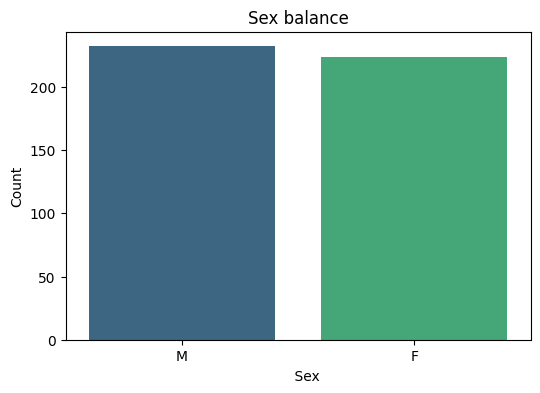

In [4]:
# sex-class balance
sex_counts = df_development['sex'].value_counts()
print("\nSex distribution in the development dataset:")
print(sex_counts)
plt.figure(figsize=(6, 4))
sns.barplot(x=sex_counts.index, y=sex_counts.values, palette='viridis')
plt.title('Sex balance')
plt.xlabel('    Sex')
plt.ylabel('Count')
plt.savefig('../figures/sex_balance.png')
plt.show()

Age distribution in the development dataset:


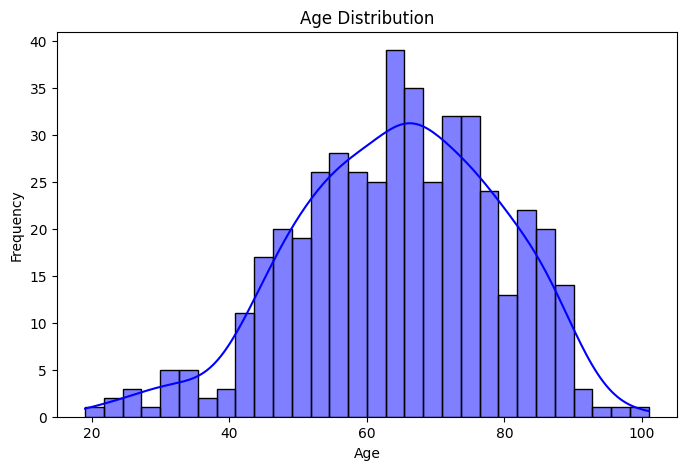

In [5]:
# age distribution
print("Age distribution in the development dataset:")
plt.figure(figsize=(8, 5))
sns.histplot(df_development['age'], bins=30, kde=True, color='blue')
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.savefig('../figures/age_distribution.png')
plt.show()

In [6]:
target_column = "age" 
print("\nTarget variable:", df_development[target_column])

# feature matrices
X, y, cpg_features, cat_features = get_feature_matrix_target_and_features(df_development, target_column)
#X = X.drop(columns=['sample_id'])  # get rid of 'sample_id' column, as it's not a feature
print("\nNumeric features (CpG sites):", cpg_features)
print("\nCategorical features:", cat_features)
print("\nTarget variable:", target_column)
print("\nCombinedFeature matrix (X) dimensions:", X.shape)  
display(X.head())

X_num = X[cpg_features]
print("\nNumeric feature matrix (X_num) dimensions:", X_num.shape)
display(X_num.head())

X_cat = X[cat_features]
print("\nCategorical feature matrix (X_cat) dimensions:", X_cat.shape)
display(X_cat.head())


Target variable: 0      79
1      46
2      78
3      46
4      59
       ..
451    73
452    73
453    84
454    54
455    64
Name: age, Length: 456, dtype: int64

Numeric features (CpG sites): Index(['cg16867657', 'cg06639320', 'cg24724428', 'cg07553761', 'cg22454769',
       'cg06784991', 'cg21572722', 'cg24079702', 'cg03032497', 'cg08234504',
       ...
       'cg17321954', 'cg17783401', 'cg26483332', 'cg22730412', 'cg14704921',
       'cg12179661', 'cg16780603', 'cg00588614', 'cg13039082', 'cg16640358'],
      dtype='object', length=1000)

Categorical features: Index(['ethnicity', 'sex'], dtype='object')

Target variable: age

CombinedFeature matrix (X) dimensions: (456, 1002)


,ethnicity,sex,cg16867657,cg06639320,cg24724428,cg07553761,cg22454769,cg06784991,cg21572722,cg24079702,...,cg17321954,cg17783401,cg26483332,cg22730412,cg14704921,cg12179661,cg16780603,cg00588614,cg13039082,cg16640358
0,Caucasian - European,M,0.672001,0.504461,0.331257,0.327287,0.572867,0.309496,0.444902,0.406582,...,0.174936,0.094635,0.163394,0.304777,0.093110,0.522947,0.736352,0.262954,0.295386,0.350803
1,Hispanic - Mexican,M,0.555411,0.389214,0.160708,0.230875,0.464971,0.223665,0.381837,0.309757,...,0.154691,0.043087,0.173311,0.343683,0.029271,0.496056,0.801962,0.291890,0.288421,0.318693
2,Caucasian - European,M,0.781318,0.554360,0.337578,0.437668,0.645529,0.309615,0.505999,0.464373,...,0.213999,0.089760,0.173368,0.338127,0.066988,0.484525,0.588307,0.276745,0.263589,0.344015
3,Hispanic - Mexican,F,0.542491,0.435584,0.228723,0.231709,0.493908,0.245836,0.424905,0.305873,...,0.198334,0.121145,0.164312,0.394890,0.044809,0.510717,0.736712,0.287274,0.333076,0.303317
4,Hispanic - Mexican,F,0.653190,0.466217,0.208453,0.284740,0.592122,0.239320,0.434244,0.401388,...,0.147234,0.035716,0.156062,0.341784,0.024294,NaN,0.828072,0.256653,0.322450,0.370363



Numeric feature matrix (X_num) dimensions: (456, 1000)


,cg16867657,cg06639320,cg24724428,cg07553761,cg22454769,cg06784991,cg21572722,cg24079702,cg03032497,cg08234504,...,cg17321954,cg17783401,cg26483332,cg22730412,cg14704921,cg12179661,cg16780603,cg00588614,cg13039082,cg16640358
0,0.672001,0.504461,0.331257,0.327287,0.572867,0.309496,0.444902,0.406582,0.249116,0.300422,...,0.174936,0.094635,0.163394,0.304777,0.093110,0.522947,0.736352,0.262954,0.295386,0.350803
1,0.555411,0.389214,0.160708,0.230875,0.464971,0.223665,0.381837,0.309757,0.208915,0.318505,...,0.154691,0.043087,0.173311,0.343683,0.029271,0.496056,0.801962,0.291890,0.288421,0.318693
2,0.781318,0.554360,0.337578,0.437668,0.645529,0.309615,0.505999,0.464373,0.326597,0.230323,...,0.213999,0.089760,0.173368,0.338127,0.066988,0.484525,0.588307,0.276745,0.263589,0.344015
3,0.542491,0.435584,0.228723,0.231709,0.493908,0.245836,0.424905,0.305873,0.209937,0.330541,...,0.198334,0.121145,0.164312,0.394890,0.044809,0.510717,0.736712,0.287274,0.333076,0.303317
4,0.653190,0.466217,0.208453,0.284740,0.592122,0.239320,0.434244,0.401388,0.242064,0.289999,...,0.147234,0.035716,0.156062,0.341784,0.024294,NaN,0.828072,0.256653,0.322450,0.370363



Categorical feature matrix (X_cat) dimensions: (456, 2)


,ethnicity,sex
0,Caucasian - European,M
1,Hispanic - Mexican,M
2,Caucasian - European,M
3,Hispanic - Mexican,F
4,Hispanic - Mexican,F


In [7]:
# create training and test sets using stratified sampling for every feature matrix
X_train, X_val, y_train, y_val = split_stratified_data(X, y, n_bins=5, test_size=0.2, random_state=42)
print("\nTraining set dimensions:", X_train.shape, y_train.shape)
print("Validation set dimensions:", X_val.shape, y_val.shape)

X_train_num = X_train[cpg_features]
X_val_num = X_val[cpg_features]
print("\nNumeric training set dimensions:", X_train_num.shape)
print("Numeric validation set dimensions:", X_val_num.shape)

X_train_cat = X_train[cat_features]
X_val_cat = X_val[cat_features]
print("\nCategorical training set dimensions:", X_train_cat.shape)
print("Categorical validation set dimensions:", X_val_cat.shape)

print("\nMissing values in training set:", X_train.isnull().sum().sum())
print("Missing values in validation set:", X_val.isnull().sum().sum())

display(X_train.head())
display(X_val.head())


Training set dimensions: (364, 1002) (364,)
Validation set dimensions: (92, 1002) (92,)

Numeric training set dimensions: (364, 1000)
Numeric validation set dimensions: (92, 1000)

Categorical training set dimensions: (364, 2)
Categorical validation set dimensions: (92, 2)

Missing values in training set: 10986
Missing values in validation set: 2726


,ethnicity,sex,cg16867657,cg06639320,cg24724428,cg07553761,cg22454769,cg06784991,cg21572722,cg24079702,...,cg17321954,cg17783401,cg26483332,cg22730412,cg14704921,cg12179661,cg16780603,cg00588614,cg13039082,cg16640358
149,Caucasian - European,F,0.664057,0.477430,0.245074,0.332128,0.612701,0.283738,0.405252,0.443891,...,0.154751,0.055624,0.193197,0.284819,0.068489,0.482724,0.751970,0.281747,0.295270,0.340189
189,Caucasian - European,F,0.746589,0.470675,0.304590,0.370931,NaN,0.262346,0.473159,0.433911,...,0.135246,0.046544,0.192949,0.266300,0.024090,0.458458,0.726835,0.244542,0.273868,0.300494
126,Caucasian - European,M,0.647457,0.427129,0.132140,0.231458,0.533029,0.224862,0.416348,0.349674,...,0.162896,0.037814,0.177285,NaN,0.041186,0.487182,0.754453,0.273842,0.305910,0.325924
21,Caucasian - European,F,0.646632,0.475820,0.282145,0.286450,0.579124,0.277806,0.432986,0.418728,...,0.169935,0.064188,0.199095,0.351231,0.034722,0.522532,0.751246,0.319237,0.300980,0.351736
414,Caucasian - European,M,0.660965,0.439389,0.250824,0.320137,0.548355,0.279881,0.426881,0.403712,...,0.153945,0.113397,0.149913,0.324508,0.049382,NaN,0.749787,0.264996,0.279931,0.346460


,ethnicity,sex,cg16867657,cg06639320,cg24724428,cg07553761,cg22454769,cg06784991,cg21572722,cg24079702,...,cg17321954,cg17783401,cg26483332,cg22730412,cg14704921,cg12179661,cg16780603,cg00588614,cg13039082,cg16640358
187,Caucasian - European,M,0.732018,0.471452,0.258051,0.313264,0.659319,0.311082,0.450151,0.428927,...,0.170167,0.031968,0.185159,NaN,0.029791,0.514257,0.772705,0.261365,NaN,0.312935
406,Caucasian - European,F,0.733659,0.504044,0.295975,0.280222,0.574641,0.315543,0.414782,0.374697,...,0.191161,0.091800,0.115576,0.310662,0.058841,0.469715,0.697561,0.242567,0.248933,0.297154
295,Caucasian - European,F,0.686840,0.543212,0.165090,0.128342,0.471130,0.232108,0.462215,0.275013,...,0.182626,0.054827,0.218012,0.343364,0.020538,0.561399,0.823408,0.235659,0.289702,0.367169
89,Caucasian - European,F,NaN,0.564684,0.317432,0.410220,0.702101,0.338811,0.458275,0.491711,...,0.191974,0.121041,0.128474,0.339894,0.075885,0.502770,0.705032,0.270762,0.294489,0.295739
107,Hispanic - Mexican,M,0.597521,0.459761,0.188552,0.234798,0.558312,0.234387,0.406172,0.385081,...,0.152774,0.055341,0.172333,0.339550,0.021606,0.541804,NaN,0.302822,0.299207,0.372438


In [13]:
display(X_train_num.head())
display(X_train_cat.head())

,cg16867657,cg06639320,cg24724428,cg07553761,cg22454769,cg06784991,cg21572722,cg24079702,cg03032497,cg08234504,...,cg17321954,cg17783401,cg26483332,cg22730412,cg14704921,cg12179661,cg16780603,cg00588614,cg13039082,cg16640358
149,0.664057,0.477430,0.245074,0.332128,0.612701,0.283738,0.405252,0.443891,0.284914,0.256668,...,0.154751,0.055624,0.193197,0.284819,0.068489,0.482724,0.751970,0.281747,0.295270,0.340189
189,0.746589,0.470675,0.304590,0.370931,NaN,0.262346,0.473159,0.433911,0.225100,0.267774,...,0.135246,0.046544,0.192949,0.266300,0.024090,0.458458,0.726835,0.244542,0.273868,0.300494
126,0.647457,0.427129,0.132140,0.231458,0.533029,0.224862,0.416348,0.349674,0.220827,0.269470,...,0.162896,0.037814,0.177285,NaN,0.041186,0.487182,0.754453,0.273842,0.305910,0.325924
21,0.646632,0.475820,0.282145,0.286450,0.579124,0.277806,0.432986,0.418728,0.261466,0.307979,...,0.169935,0.064188,0.199095,0.351231,0.034722,0.522532,0.751246,0.319237,0.300980,0.351736
414,0.660965,0.439389,0.250824,0.320137,0.548355,0.279881,0.426881,0.403712,0.233897,0.271172,...,0.153945,0.113397,0.149913,0.324508,0.049382,NaN,0.749787,0.264996,0.279931,0.346460


,ethnicity,sex
149,Caucasian - European,F
189,Caucasian - European,F
126,Caucasian - European,M
21,Caucasian - European,F
414,Caucasian - European,M


Here we created the combined feature matrix (cpg + cat features), 
the numerical feature matrix (cpg features only) and the categorical feature matrix 
 (cat features only - metadata) for the training and validation sets.

All the preprocessing steps (imputation, scaling, encoding) will be fit strictly on the 
training set of each feature matrix and then applied to the validation set, to avoid data leakage.

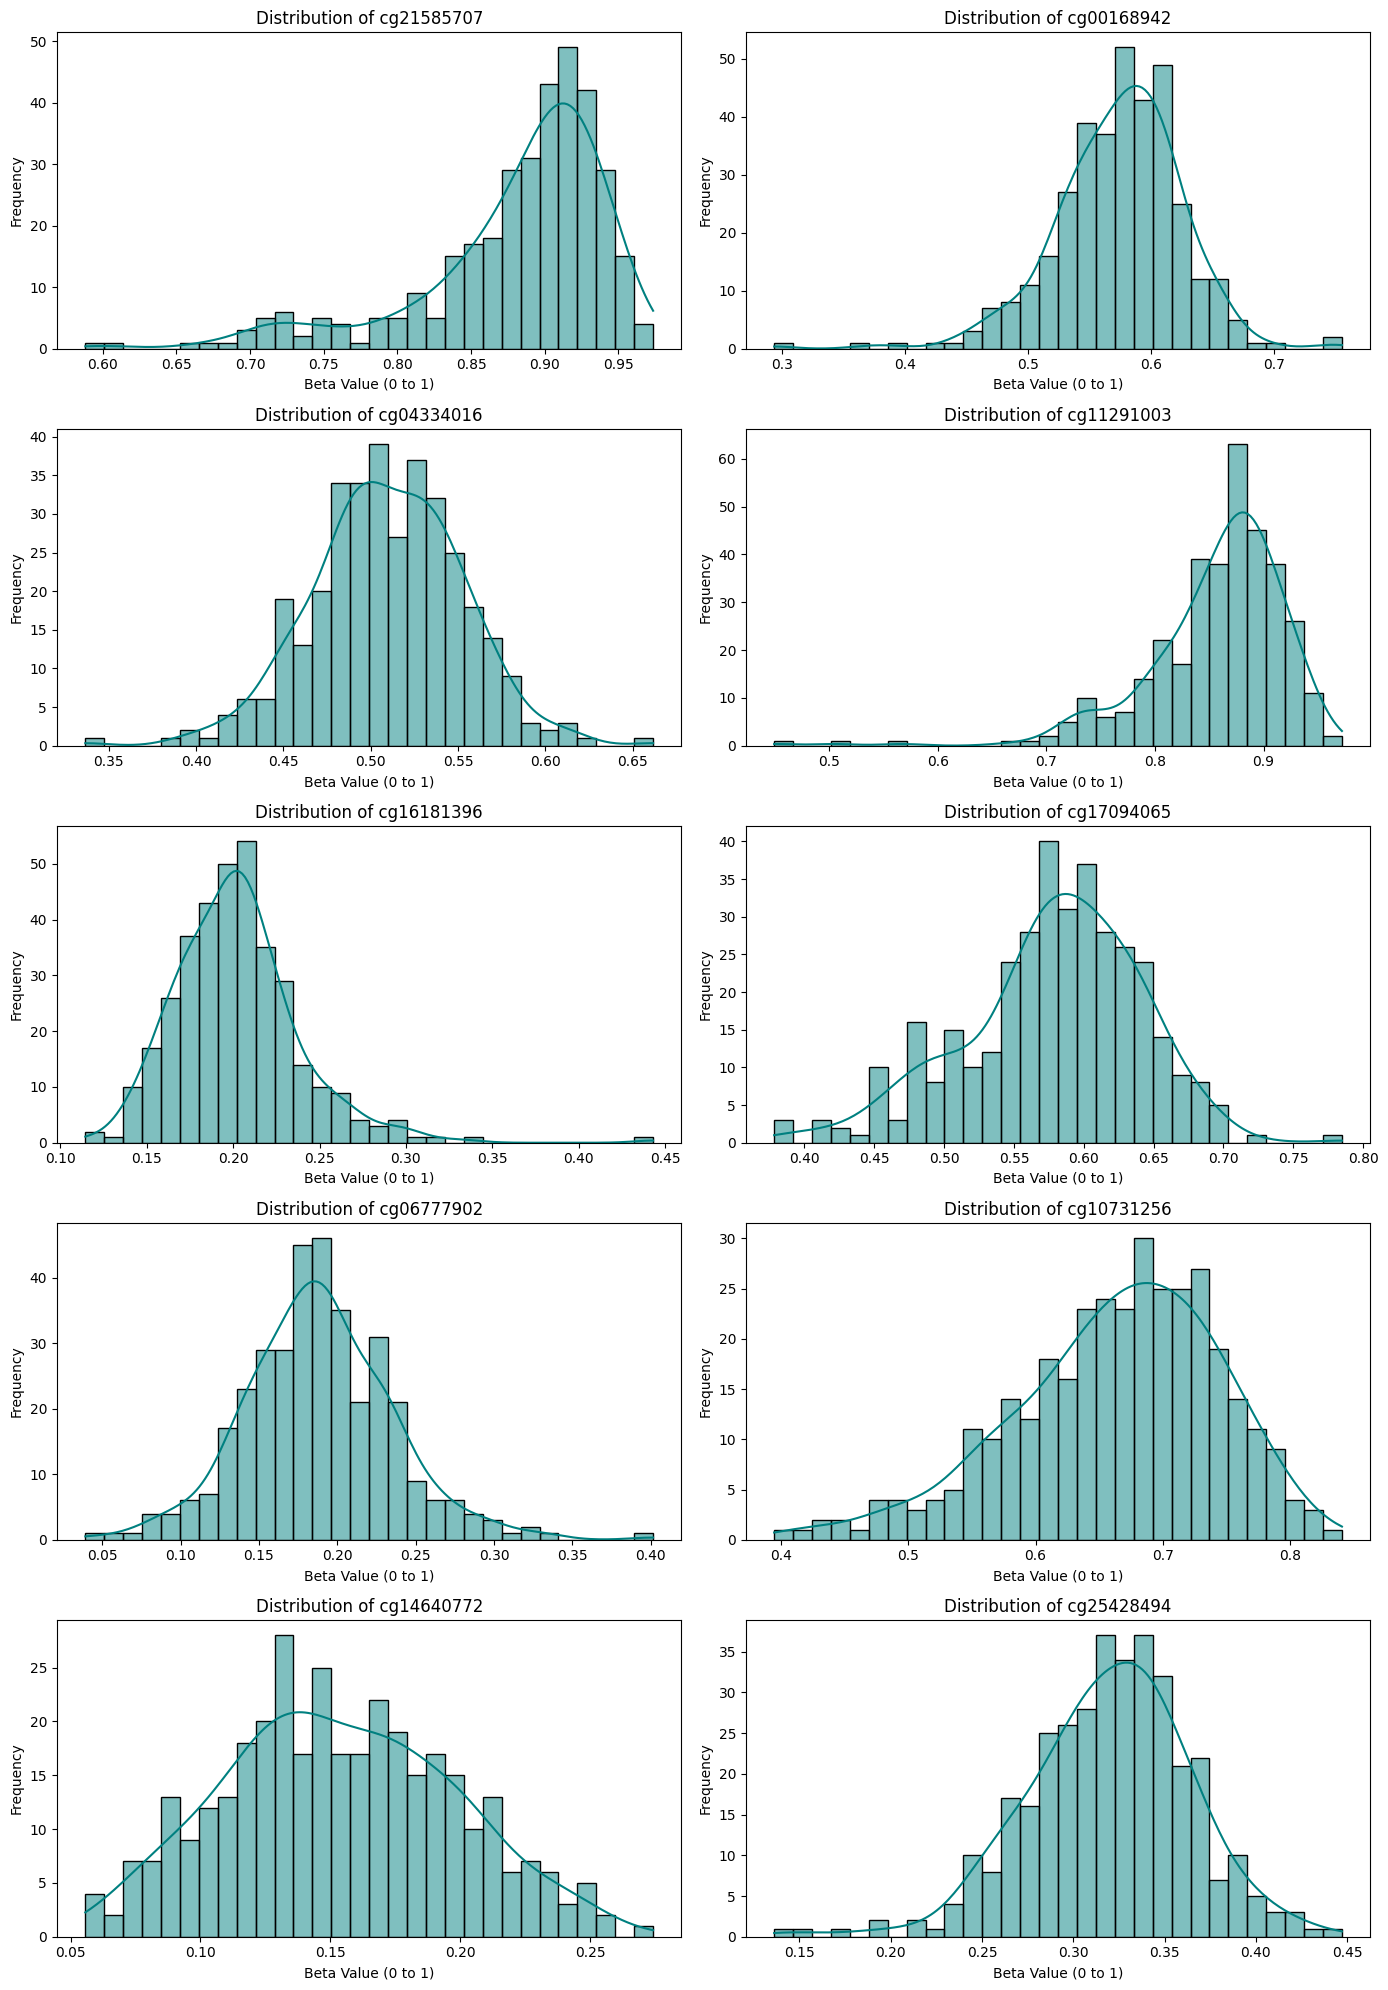

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# investigation of the numeric features (CpG sites)
# visualizing the distribution of 10 randomly chosen CpG features in the training set 
np.random.seed(42)
random_cpgs = np.random.choice(cpg_features, size=10, replace=False)

fig, axes = plt.subplots(5, 2, figsize=(14, 20))
axes = axes.flatten()

for i, cpg in enumerate(random_cpgs):
    sns.histplot(X_train[cpg].dropna(), bins=30, kde=True, ax=axes[i], color='teal')
    axes[i].set_title(f'Distribution of {cpg}')
    axes[i].set_xlabel('Beta Value (0 to 1)')
    axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('../figures/cpg_distributions.png')
plt.show()

From this random selection of CpG features, we can see that the distributions are quite varied 
with somefeatures showing a more uniform distribution and others being more skewed.
The skewness and presence of outliers in some cpg features suggest that using the median who 
is robust to outliers as the imputation strategy for missing values in the numeric features is # a reasonable choice.

In [9]:
# combined feature matrix preprocessing

my_preprocessor = build_preprocessor(cpg_features, cat_features)

X_train_preprocessed = my_preprocessor.fit_transform(X_train)
X_val_preprocessed = my_preprocessor.transform(X_val)
print("\nPreprocessed training set dimensions:", X_train_preprocessed.shape)
print("Preprocessed validation set dimensions:", X_val_preprocessed.shape)



Preprocessed training set dimensions: (364, 1004)
Preprocessed validation set dimensions: (92, 1004)


In [10]:
print(X_train_preprocessed[:5])
my_preprocessor.get_feature_names_out()

[[-0.0876171   0.08729114 -0.17008725 ...  0.          1.
   0.        ]
 [ 1.00721067 -0.04430718  0.62407454 ...  0.          1.
   0.        ]
 [-0.30782803 -0.89253287 -1.67701792 ...  0.          0.
   1.        ]
 [-0.31876548  0.05592602  0.32458025 ...  0.          1.
   0.        ]
 [-0.12863289 -0.6537298  -0.09335659 ...  0.          0.
   1.        ]]


array(['num__cg16867657', 'num__cg06639320', 'num__cg24724428', ...,
       'cat__ethnicity_Hispanic - Mexican', 'cat__sex_F', 'cat__sex_M'],
      shape=(1004,), dtype=object)

,n,age_mean,age_std,female_ratio
dataset,,,,
train,364,64.26,14.64,0.48
val,92,65.21,14.67,0.52


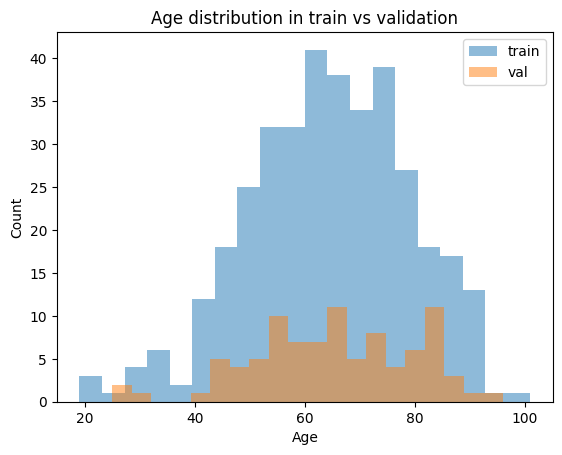

In [ ]:
# check that the age distribution is similar in train and validation sets
# i.e., that the stratified sampling (by age) worked as intended

summary = pd.DataFrame({
    "dataset":      ["train", "val"],
    "n":            [len(y_train), len(y_val)],
    "age_mean":     [round(y_train.mean(), 2), round(y_val.mean(), 2)],
    "age_std":      [round(y_train.std(), 2),  round(y_val.std(), 2)],
    "female_ratio": [
        round((X_train["sex"] == "F").mean(), 2),
        round((X_val["sex"] == "F").mean(), 2)
    ]
}).set_index("dataset")

display(summary)

plt.hist(y_train, bins=20, alpha=0.5)
plt.hist(y_val, bins=20, alpha=0.5)

plt.legend(["train","val"])
plt.xlabel("Age")
plt.ylabel("Count")
plt.title("Age distribution in train vs validation")
plt.savefig('../figures/age_distribution_train_val.png')
plt.show()

Τhe stratified sampling (by age) seems to have worked well, 
as the age distributions in the training and validation sets are quite similar, 
with comparable means and standard deviations

In [ ]:
# numeric and categorical feature matrices preprocessing 

from src.functions import build_num_preprocessor, build_cat_preprocessor

num_preprocessor = build_num_preprocessor()
cat_preprocessor = build_cat_preprocessor()

X_train_num_preprocessed = num_preprocessor.fit_transform(X_train_num)
X_val_num_preprocessed   = num_preprocessor.transform(X_val_num)
print("Preprocessed numeric training set dimensions:", X_train_num_preprocessed.shape)

X_train_cat_preprocessed = cat_preprocessor.fit_transform(X_train_cat)
X_val_cat_preprocessed   = cat_preprocessor.transform(X_val_cat)
print("Preprocessed categorical training set dimensions:", X_train_cat_preprocessed.shape)

Preprocessed numeric training set dimensions: (364, 1000)
Preprocessed categorical training set dimensions: (364, 4)
